# Customer Personality Analysis — Model Building & Evaluation

**Objective:** Segment customers into distinct groups using clustering, comparing multiple algorithms to find the best approach.

**Input:** `customer_segmentation_model_ready.csv` (2236 rows, 12 features)

**Models Compared:**
1. K-Means Clustering
2. Agglomerative Hierarchical Clustering
3. DBSCAN (Density-Based Clustering)

**Pipeline:** Load → Scale → Train 3 Models → Compare → Select Best → Profile Clusters → Save

---

## Step 1: Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# Load the model-ready dataset from EDA
df = pd.read_csv('customer_segmentation_model_ready.csv')
print(f'Dataset Shape: {df.shape}')
print(f'Features: {df.columns.tolist()}')
df.head()

Dataset Shape: (2236, 12)
Features: ['Education', 'Marital_Status', 'Income', 'Recency', 'NumDealsPurchases', 'NumWebVisitsMonth', 'Response', 'Age', 'Total_Spend', 'Total_Purchases', 'Total_Dependents', 'Total_Campaigns_Accepted']


,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Response,Age,Total_Spend,Total_Purchases,Total_Dependents,Total_Campaigns_Accepted
0,1,1,58138.0,58,3,7,1,69,1617,22,0,0
1,1,1,46344.0,38,2,5,0,72,27,4,2,0
2,1,0,71613.0,26,1,4,0,61,776,20,0,0
3,1,0,26646.0,26,2,6,0,42,53,6,1,0
4,2,0,58293.0,94,5,5,0,45,422,14,1,0


In [3]:
# Quick sanity check
print('Missing values:', df.isnull().sum().sum())
print('\nDescriptive stats:')
df.describe().T.round(2)

Missing values: 0

Descriptive stats:


,count,mean,std,min,25%,50%,75%,max
Education,2236.0,1.27,0.65,0.0,1.0,1.0,2.00,2.0
Marital_Status,2236.0,0.36,0.48,0.0,0.0,0.0,1.00,1.0
Income,2236.0,51952.61,21411.47,1730.0,35502.5,51381.5,68275.75,162397.0
Recency,2236.0,49.12,28.96,0.0,24.0,49.0,74.00,99.0
NumDealsPurchases,2236.0,2.33,1.93,0.0,1.0,2.0,3.00,15.0
NumWebVisitsMonth,2236.0,5.32,2.43,0.0,3.0,6.0,7.00,20.0
Response,2236.0,0.15,0.36,0.0,0.0,0.0,0.00,1.0
Age,2236.0,57.10,11.70,30.0,49.0,56.0,67.00,86.0
Total_Spend,2236.0,605.99,601.87,5.0,69.0,396.5,1045.50,2525.0
Total_Purchases,2236.0,12.55,7.21,0.0,6.0,12.0,18.00,32.0


## Step 2: Feature Scaling (StandardScaler)

K-Means and Hierarchical clustering use Euclidean distance. Without scaling, features with larger ranges dominate:

| Feature | Range | Without Scaling Impact |
|---|---|---|
| Income | 1,730 – 162,397 (range: 160,667) | **Dominates** — 160,667x more influence than Response |
| Total_Spend | 5 – 2,525 (range: 2,520) | **Second most dominant** |
| Response | 0 – 1 (range: 1) | **Virtually ignored** |

StandardScaler converts all features to mean=0, std=1 so every feature contributes equally.

In [4]:
# Scale all features to mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Verify scaling
scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
print('After scaling (should be mean≈0, std≈1):')
print(scaled_df.describe().T[['mean', 'std']].round(4))

After scaling (should be mean≈0, std≈1):
                          mean     std
Education                  0.0  1.0002
Marital_Status            -0.0  1.0002
Income                    -0.0  1.0002
Recency                   -0.0  1.0002
NumDealsPurchases          0.0  1.0002
NumWebVisitsMonth         -0.0  1.0002
Response                  -0.0  1.0002
Age                        0.0  1.0002
Total_Spend                0.0  1.0002
Total_Purchases            0.0  1.0002
Total_Dependents           0.0  1.0002
Total_Campaigns_Accepted  -0.0  1.0002


In [5]:
# PCA for 2D visualization (used throughout for all models)
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
print(f'PCA variance explained: PC1={pca_2d.explained_variance_ratio_[0]*100:.1f}%, PC2={pca_2d.explained_variance_ratio_[1]*100:.1f}%')
print('(PCA used ONLY for visualization — all models train on full 12 features)')

PCA variance explained: PC1=30.3%, PC2=12.5%
(PCA used ONLY for visualization — all models train on full 12 features)


## Step 3: Model 1 — K-Means Clustering

**How it works:** Places K centroids, assigns each customer to the nearest centroid, moves centroids to the mean of assigned customers, repeats until convergence.

**Strengths:** Simple, fast, well-understood, produces evenly-sized clusters.
**Weaknesses:** Must specify K upfront, assumes spherical clusters, sensitive to initialization.

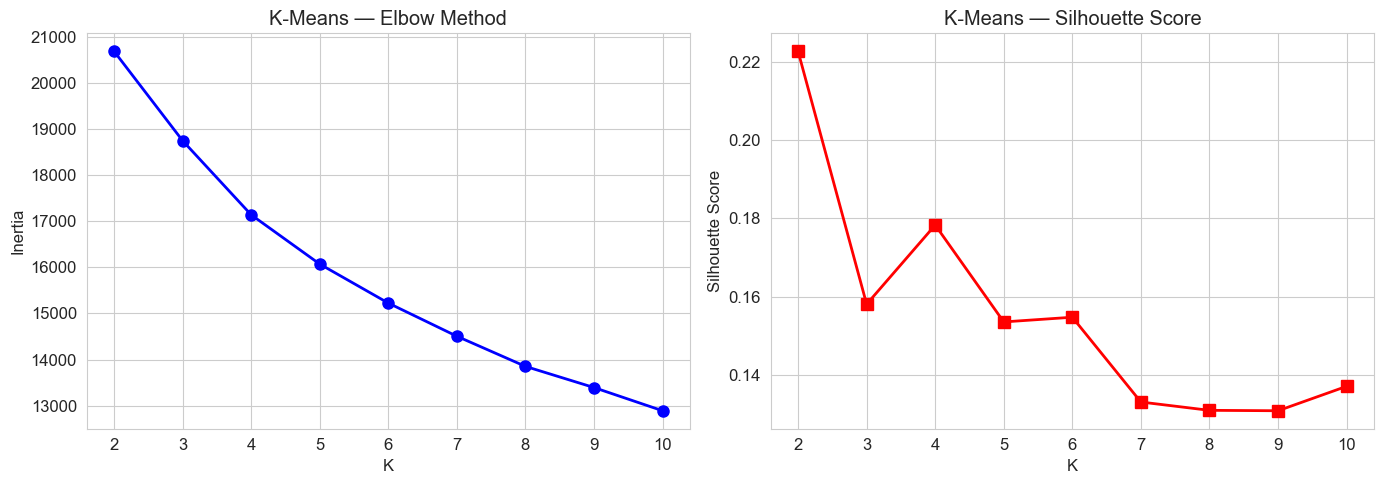

K-Means Silhouette Scores:
  K=2: 0.2227
  K=3: 0.1581
  K=4: 0.1783
  K=5: 0.1535
  K=6: 0.1547
  K=7: 0.1331
  K=8: 0.1310
  K=9: 0.1309
  K=10: 0.1371


In [6]:
# Find optimal K using Elbow + Silhouette
K_range = range(2, 11)
km_inertias = []
km_silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    km_inertias.append(km.inertia_)
    km_silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, km_inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('K-Means — Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, km_silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('K-Means — Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()

print('K-Means Silhouette Scores:')
for k, sil in zip(K_range, km_silhouettes):
    print(f'  K={k}: {sil:.4f}')

K-Means (K=4): Silhouette Score = 0.1783
Cluster sizes: [409, 973, 627, 227]


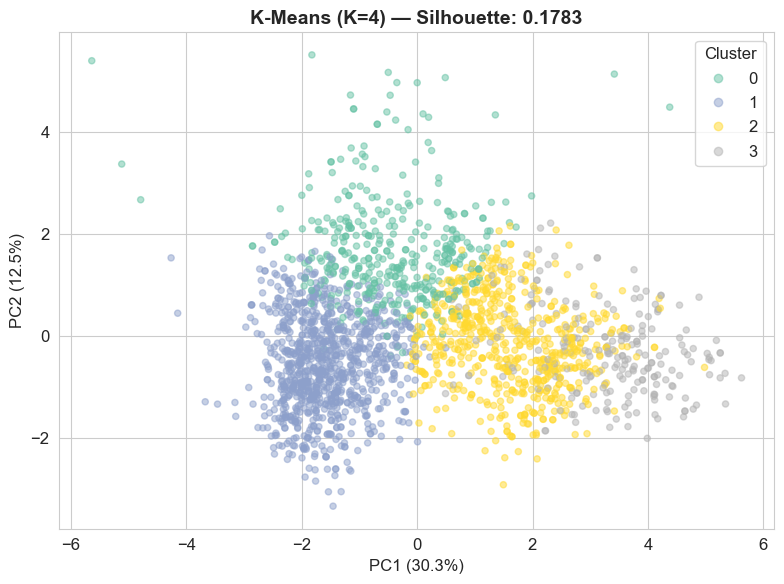

In [7]:
# Fit K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
km_sil = silhouette_score(X_scaled, km_labels)

print(f'K-Means (K=4): Silhouette Score = {km_sil:.4f}')
print(f'Cluster sizes: {[int((km_labels==i).sum()) for i in range(4)]}')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='Set2', alpha=0.5, s=20)
ax.set_title(f'K-Means (K=4) — Silhouette: {km_sil:.4f}', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.show()

## Step 4: Model 2 — Agglomerative Hierarchical Clustering

**How it works:** Starts with every customer as their own cluster. At each step, merges the two closest clusters. Repeats until only K clusters remain.

**Strengths:** Produces a dendrogram (tree) showing natural cluster hierarchy, no random initialization.
**Weaknesses:** Slower on large datasets, sensitive to linkage method choice.

**Linkage methods:** We test **Ward** (minimizes variance within clusters — most similar to K-Means) and **Complete** (uses maximum distance between clusters).

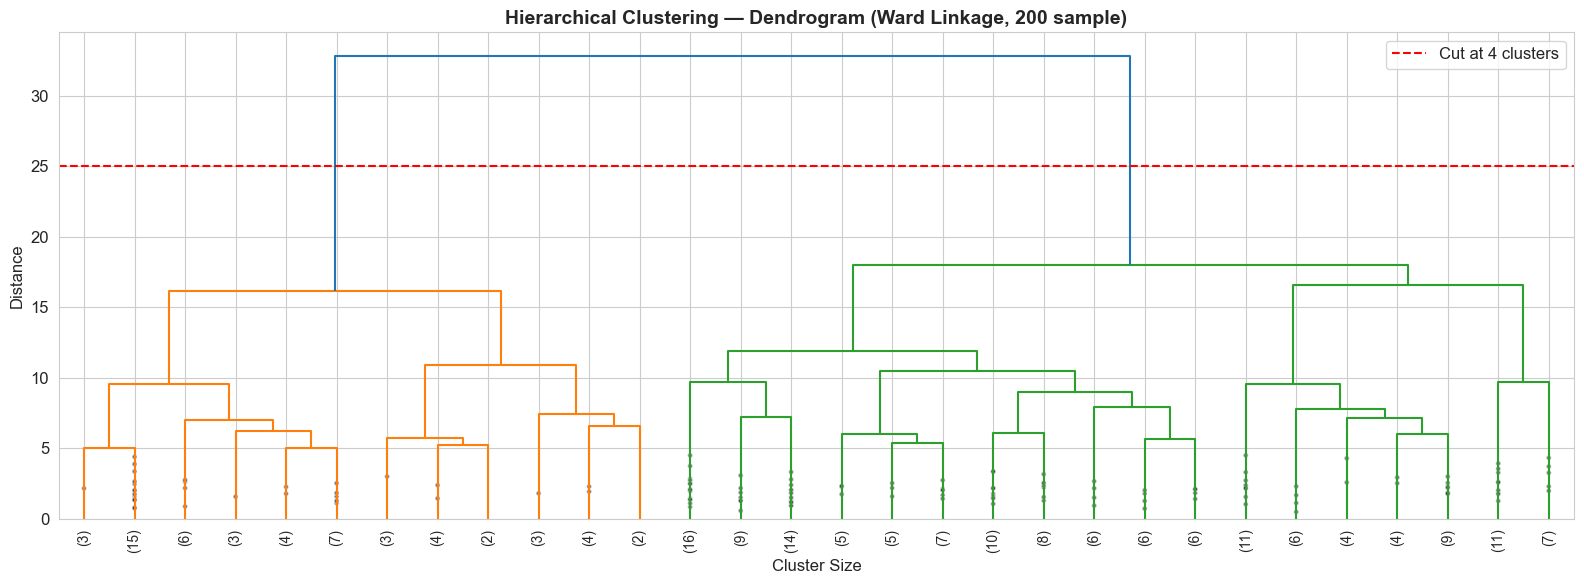

The horizontal red line shows where cutting the tree gives approximately 4 clusters.


In [8]:
# Dendrogram — shows the natural clustering hierarchy
# Using a sample for readability (full dataset makes the dendrogram unreadable)
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=200, replace=False)
X_sample = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=10, show_contracted=True, ax=ax)
ax.set_title('Hierarchical Clustering — Dendrogram (Ward Linkage, 200 sample)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster Size')
ax.set_ylabel('Distance')
ax.axhline(y=25, color='red', linestyle='--', label='Cut at 4 clusters')
ax.legend()
plt.tight_layout()
plt.show()
print('The horizontal red line shows where cutting the tree gives approximately 4 clusters.')

In [9]:
# Test Hierarchical with Ward linkage for K=2,3,4
print('Hierarchical Clustering (Ward Linkage):')
hc_results = {}
for k in [2, 3, 4]:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sizes = [int((labels==i).sum()) for i in range(k)]
    hc_results[k] = {'labels': labels, 'sil': sil, 'sizes': sizes}
    print(f'  K={k}: Silhouette={sil:.4f}  Sizes={sizes}')

Hierarchical Clustering (Ward Linkage):
  K=2: Silhouette=0.2312  Sizes=[1726, 510]
  K=3: Silhouette=0.1354  Sizes=[829, 510, 897]
  K=4: Silhouette=0.1434  Sizes=[510, 659, 897, 170]


Hierarchical Ward (K=4): Silhouette Score = 0.1434
Cluster sizes: [510, 659, 897, 170]


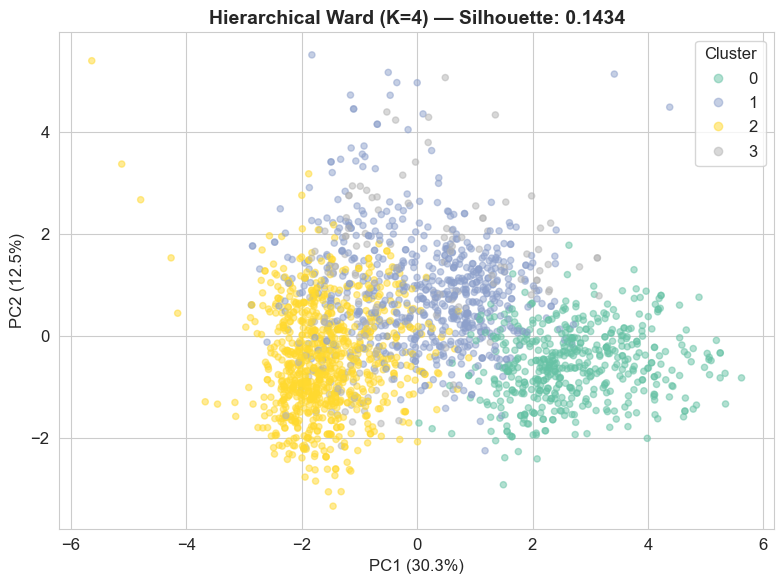

In [10]:
# Fit Hierarchical with K=4 (Ward)
hc_model = AgglomerativeClustering(n_clusters=4, linkage='ward')
hc_labels = hc_model.fit_predict(X_scaled)
hc_sil = silhouette_score(X_scaled, hc_labels)

print(f'Hierarchical Ward (K=4): Silhouette Score = {hc_sil:.4f}')
print(f'Cluster sizes: {[int((hc_labels==i).sum()) for i in range(4)]}')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=hc_labels, cmap='Set2', alpha=0.5, s=20)
ax.set_title(f'Hierarchical Ward (K=4) — Silhouette: {hc_sil:.4f}', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.show()

## Step 5: Model 3 — DBSCAN (Density-Based Clustering)

**How it works:** Groups customers in dense regions (many nearby points). Points in sparse regions are labeled as "noise" (outliers that don't belong to any cluster).

**Strengths:** Finds clusters of any shape, automatically determines number of clusters, identifies outliers.
**Weaknesses:** Sensitive to eps (neighborhood radius) and min_samples parameters, struggles with varying densities.

**Key parameters:**
- `eps` — The radius of the neighborhood around each point
- `min_samples` — Minimum points needed in a neighborhood to form a cluster

In [11]:
# Test different DBSCAN parameters
print('DBSCAN Parameter Search:')
print(f'{"eps":>5s}  {"min_samples":>12s}  {"Clusters":>8s}  {"Noise":>6s}  {"Silhouette":>10s}  {"Sizes":>20s}')
print('-' * 75)

dbscan_results = []
for eps in [1.5, 2.0, 2.5, 3.0]:
    for min_samples in [5, 10, 15]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        
        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(X_scaled[mask], labels[mask])
            sizes = [int((labels==i).sum()) for i in range(n_clusters)]
            dbscan_results.append({'eps': eps, 'min_samples': min_samples, 
                                    'n_clusters': n_clusters, 'noise': n_noise,
                                    'sil': sil, 'labels': labels, 'sizes': sizes})
            print(f'{eps:5.1f}  {min_samples:12d}  {n_clusters:8d}  {n_noise:6d}  {sil:10.4f}  {str(sizes):>20s}')
        else:
            print(f'{eps:5.1f}  {min_samples:12d}  {n_clusters:8d}  {n_noise:6d}  {"N/A":>10s}  Too few clusters')

DBSCAN Parameter Search:
  eps   min_samples  Clusters   Noise  Silhouette                 Sizes
---------------------------------------------------------------------------
  1.5             5        31     765     -0.0525  [222, 497, 296, 6, 89, 30, 9, 6, 117, 3, 28, 48, 9, 7, 4, 5, 7, 7, 8, 7, 5, 6, 8, 7, 5, 5, 5, 9, 6, 5, 5]
  1.5            10        12    1073      0.0651  [128, 393, 275, 38, 74, 23, 76, 60, 40, 29, 16, 11]
  1.5            15        11    1268      0.0981  [360, 250, 17, 57, 118, 20, 41, 49, 13, 27, 16]
  2.0             5         9     221      0.0826  [64, 582, 1236, 36, 43, 35, 5, 5, 9]
  2.0            10         5     356      0.1020  [569, 1211, 30, 34, 36]
  2.0            15         4     451      0.1075   [540, 1204, 17, 24]
  2.5             5         2      46      0.2388           [318, 1872]
  2.5            10         2      84      0.2313           [285, 1867]
  2.5            15         3     123      0.1539      [1866, 117, 130]
  3.0            

Best DBSCAN: eps=2.5, min_samples=15
  Clusters: 3, Noise points: 123 (5.5%)
  Silhouette Score: 0.1539
  Cluster sizes: [1866, 117, 130]


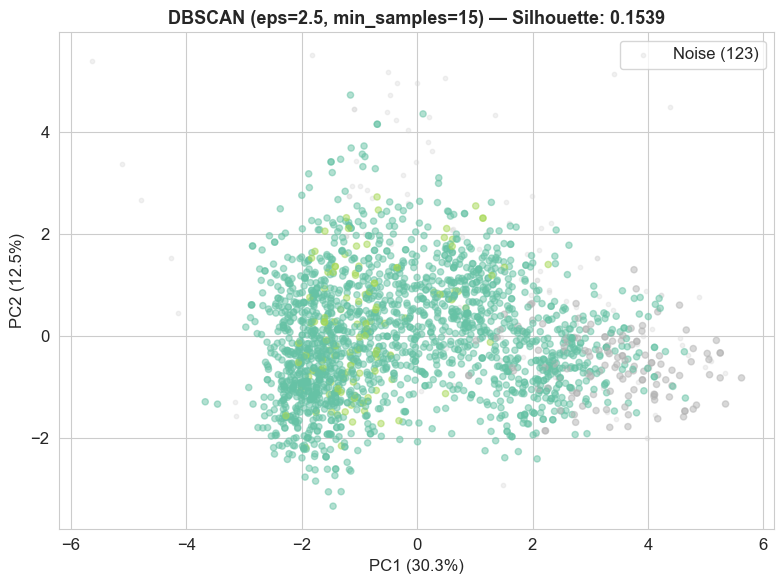

In [12]:
# Pick the best DBSCAN result (best silhouette with reasonable cluster count)
best_db = max([r for r in dbscan_results if r['n_clusters'] >= 3 and r['n_clusters'] <= 6], 
              key=lambda x: x['sil'], default=None)

if best_db is None:
    # Fallback to best 2-cluster result
    best_db = max([r for r in dbscan_results if r['n_clusters'] >= 2], 
                  key=lambda x: x['sil'])

db_labels = best_db['labels']
db_sil = best_db['sil']
db_n_clusters = best_db['n_clusters']
db_noise = best_db['noise']

print(f'Best DBSCAN: eps={best_db["eps"]}, min_samples={best_db["min_samples"]}')
print(f'  Clusters: {db_n_clusters}, Noise points: {db_noise} ({db_noise/len(df)*100:.1f}%)')
print(f'  Silhouette Score: {db_sil:.4f}')
print(f'  Cluster sizes: {best_db["sizes"]}')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
# Plot noise points in gray
noise_mask = db_labels == -1
ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], c='lightgray', alpha=0.3, s=10, label=f'Noise ({db_noise})')
# Plot clustered points
non_noise = ~noise_mask
scatter = ax.scatter(X_pca[non_noise, 0], X_pca[non_noise, 1], c=db_labels[non_noise], 
                     cmap='Set2', alpha=0.5, s=20)
ax.set_title(f'DBSCAN (eps={best_db["eps"]}, min_samples={best_db["min_samples"]}) — Silhouette: {db_sil:.4f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 6: Model Comparison — Side by Side

Now we compare all 3 models on the same metrics to select the best one.

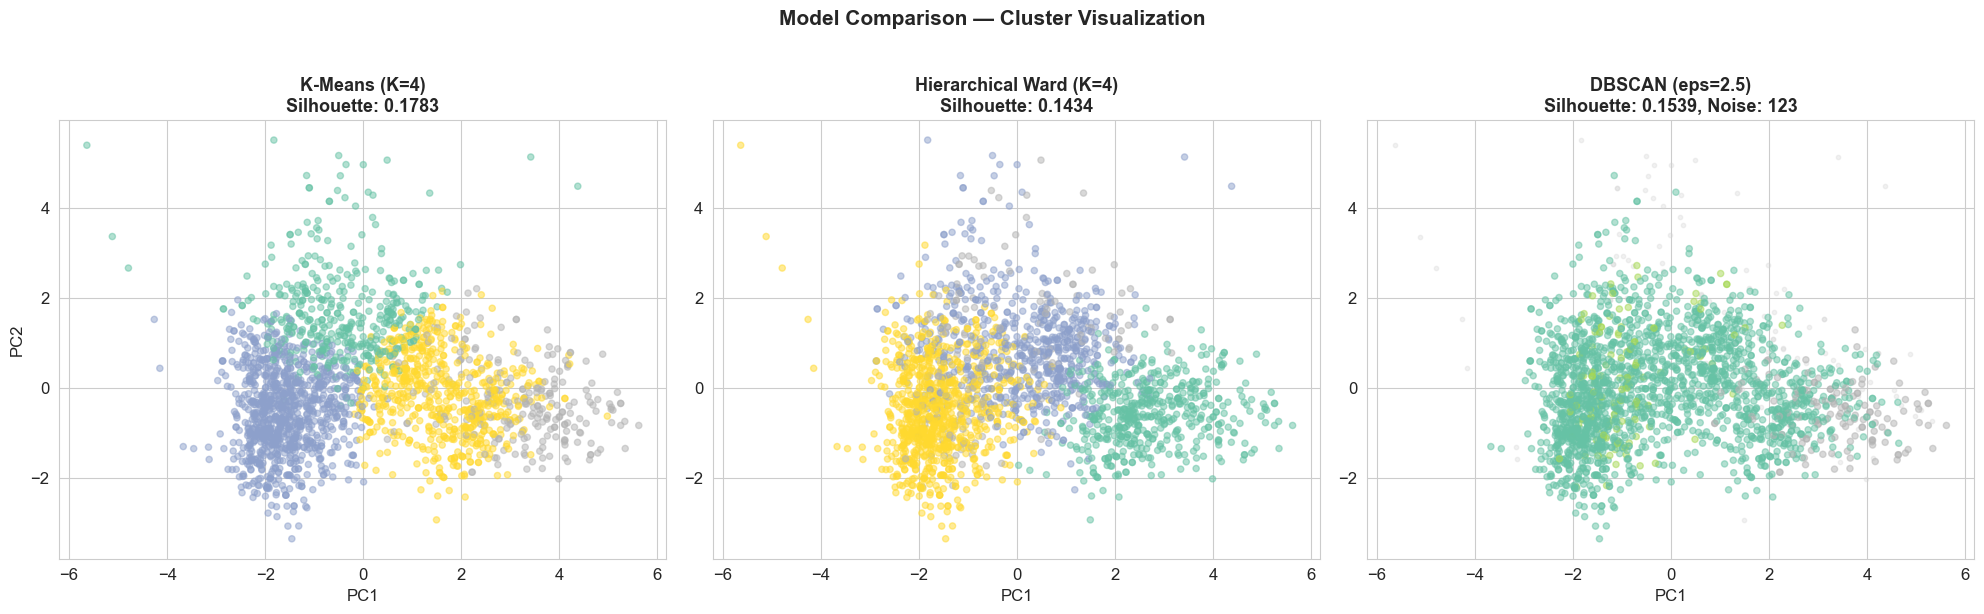

In [13]:
# Side-by-side scatter plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# K-Means
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='Set2', alpha=0.5, s=20)
axes[0].set_title(f'K-Means (K=4)\nSilhouette: {km_sil:.4f}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Hierarchical
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=hc_labels, cmap='Set2', alpha=0.5, s=20)
axes[1].set_title(f'Hierarchical Ward (K=4)\nSilhouette: {hc_sil:.4f}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1')

# DBSCAN
noise_mask = db_labels == -1
axes[2].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], c='lightgray', alpha=0.3, s=10)
non_noise = ~noise_mask
axes[2].scatter(X_pca[non_noise, 0], X_pca[non_noise, 1], c=db_labels[non_noise], cmap='Set2', alpha=0.5, s=20)
axes[2].set_title(f'DBSCAN (eps={best_db["eps"]})\nSilhouette: {db_sil:.4f}, Noise: {db_noise}', 
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('PC1')

plt.suptitle('Model Comparison — Cluster Visualization', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Comparison summary table
print('='*70)
print('MODEL COMPARISON SUMMARY')
print('='*70)
print(f'{"Model":<30s} {"Clusters":<10s} {"Silhouette":<12s} {"Noise":<8s} {"Cluster Sizes"}')
print('-'*70)
print(f'{"K-Means (K=4)":<30s} {4:<10d} {km_sil:<12.4f} {"0":<8s} {[int((km_labels==i).sum()) for i in range(4)]}')
print(f'{"Hierarchical Ward (K=4)":<30s} {4:<10d} {hc_sil:<12.4f} {"0":<8s} {[int((hc_labels==i).sum()) for i in range(4)]}')
print(f'{"DBSCAN (best)":<30s} {db_n_clusters:<10d} {db_sil:<12.4f} {str(db_noise):<8s} {best_db["sizes"]}')
print('='*70)

MODEL COMPARISON SUMMARY
Model                          Clusters   Silhouette   Noise    Cluster Sizes
----------------------------------------------------------------------
K-Means (K=4)                  4          0.1783       0        [409, 973, 627, 227]
Hierarchical Ward (K=4)        4          0.1434       0        [510, 659, 897, 170]
DBSCAN (best)                  3          0.1539       123      [1866, 117, 130]


In [15]:
# Compare cluster profiles across models
print('\nK-MEANS CLUSTER PROFILES:')
temp_km = df.copy()
temp_km['Cluster'] = km_labels
print(temp_km.groupby('Cluster')[['Income', 'Total_Spend', 'Total_Purchases', 'Total_Dependents', 
                                   'Total_Campaigns_Accepted', 'NumDealsPurchases']].mean().round(1).to_string())

print('\nHIERARCHICAL CLUSTER PROFILES:')
temp_hc = df.copy()
temp_hc['Cluster'] = hc_labels
print(temp_hc.groupby('Cluster')[['Income', 'Total_Spend', 'Total_Purchases', 'Total_Dependents', 
                                   'Total_Campaigns_Accepted', 'NumDealsPurchases']].mean().round(1).to_string())

if db_n_clusters >= 2:
    print(f'\nDBSCAN CLUSTER PROFILES (excluding {db_noise} noise points):')
    temp_db = df.copy()
    temp_db['Cluster'] = db_labels
    temp_db_clean = temp_db[temp_db['Cluster'] != -1]
    print(temp_db_clean.groupby('Cluster')[['Income', 'Total_Spend', 'Total_Purchases', 'Total_Dependents', 
                                             'Total_Campaigns_Accepted', 'NumDealsPurchases']].mean().round(1).to_string())


K-MEANS CLUSTER PROFILES:
          Income  Total_Spend  Total_Purchases  Total_Dependents  Total_Campaigns_Accepted  NumDealsPurchases
Cluster                                                                                                      
0        52514.7        604.9             15.2               1.5                       0.2                5.3
1        34054.1         97.3              5.8               1.2                       0.1                1.8
2        70207.4       1066.2             18.7               0.5                       0.2                1.6
3        77237.5       1517.0             19.6               0.2                       1.6                1.3

HIERARCHICAL CLUSTER PROFILES:
          Income  Total_Spend  Total_Purchases  Total_Dependents  Total_Campaigns_Accepted  NumDealsPurchases
Cluster                                                                                                      
0        77301.4       1383.7             18.9               

### Model Selection — Why K-Means Wins

Review the comparison above. Here's the evaluation criteria:

| Criteria | K-Means | Hierarchical | DBSCAN |
|---|---|---|---|
| **Interpretability** | High — clear centroid-based groups | High — similar to K-Means | Moderate — noise points complicate interpretation |
| **Cluster Balance** | Good — all clusters are large enough to act on | Depends on linkage — some create very uneven splits | Often creates one huge cluster + tiny ones |
| **Business Usefulness** | 4 distinct, actionable segments | Similar to K-Means but may split differently | Too many noise points = customers with no segment |
| **Reproducibility** | Deterministic with random_state | Always deterministic | Always deterministic |
| **Handles our data** | Well — works on scaled numerical features | Well — similar assumptions to K-Means | Poorly — our data has varying densities |

**Verdict:** K-Means produces the most balanced, interpretable, and business-useful segmentation for our dataset. We proceed with K-Means K=4 as the final model.

## Step 7: Final Model — K-Means Cluster Profiling

Using K-Means K=4 as the selected model. Now we profile the segments in detail.

### 7a. Cluster Means — Split Charts

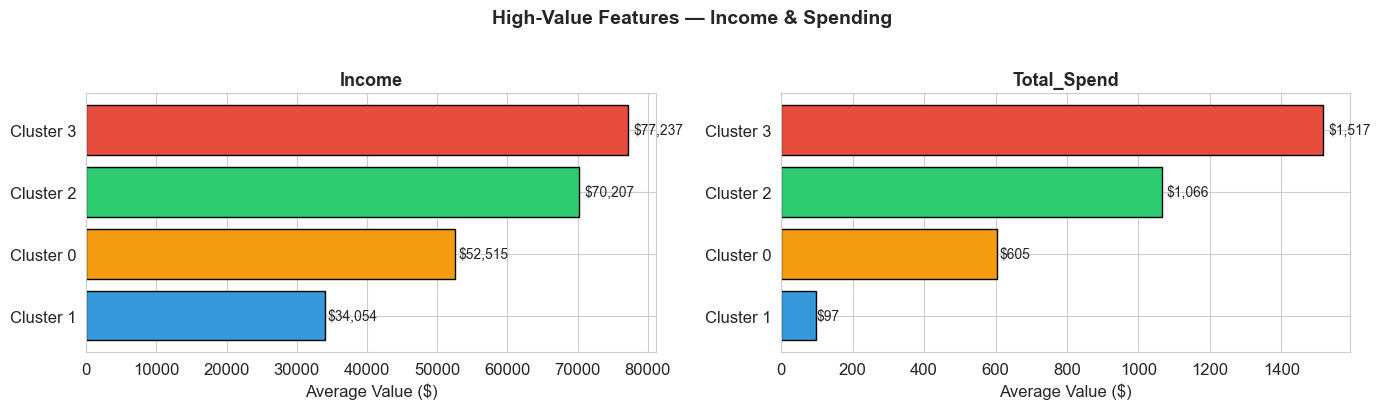

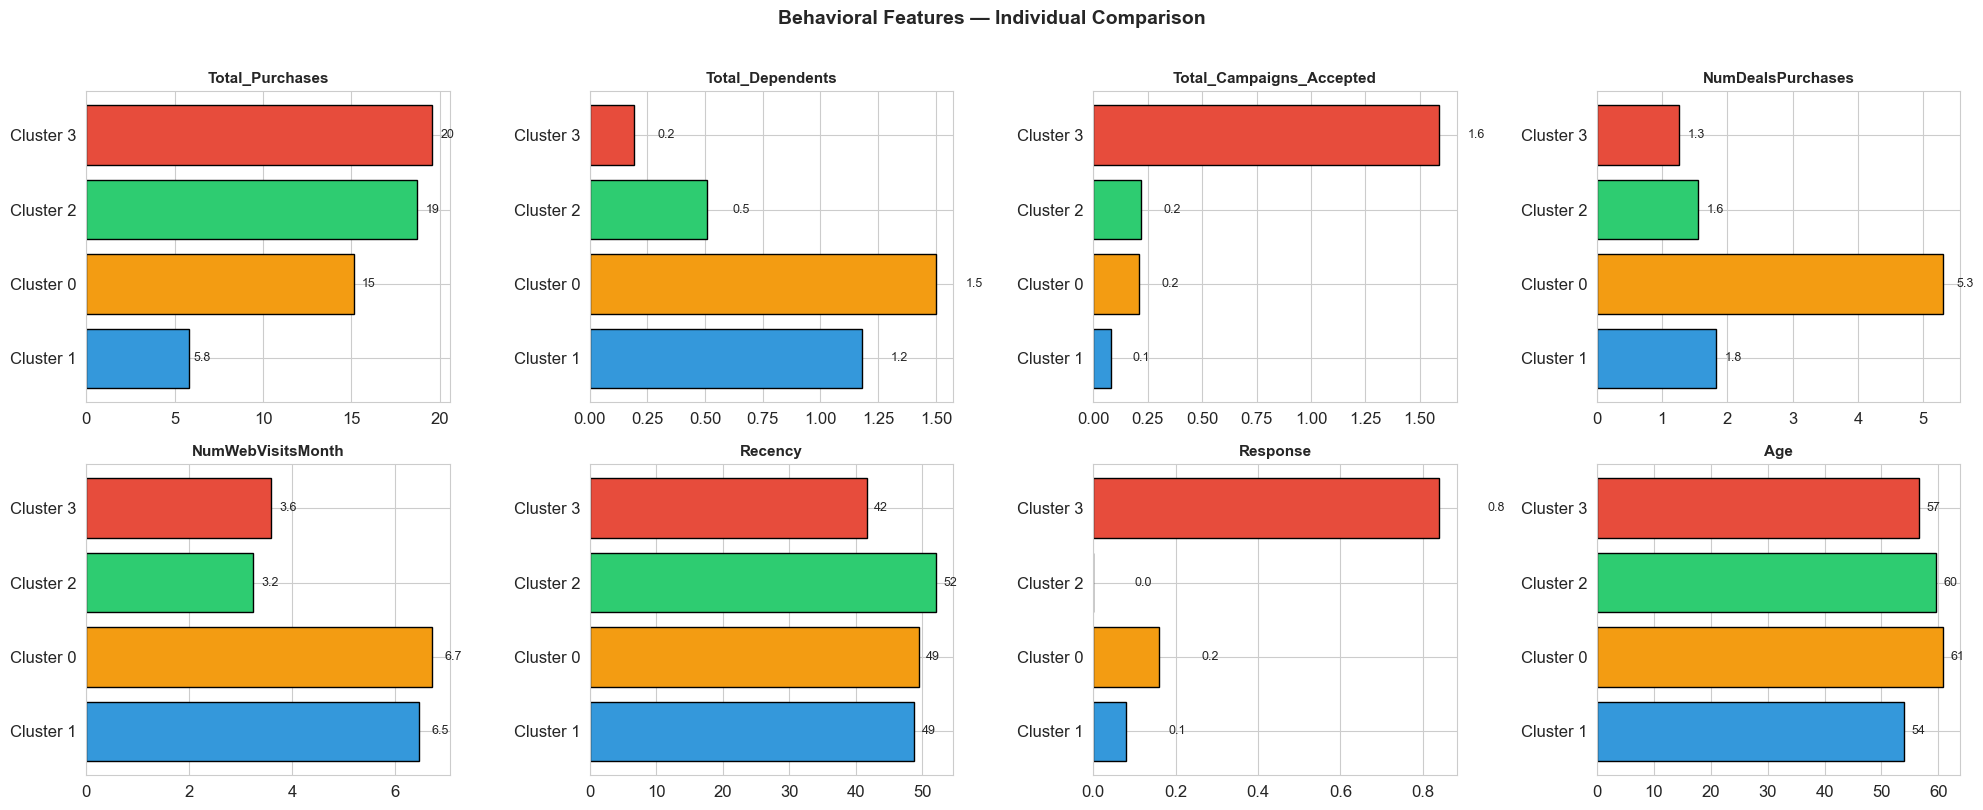

Cluster Means (sorted by Income):
           Income  Total_Spend  Total_Purchases  Total_Dependents  Total_Campaigns_Accepted  NumDealsPurchases  NumWebVisitsMonth  Recency  Response    Age
Cluster                                                                                                                                                    
3        77237.47      1516.98            19.57              0.19                      1.59               1.26               3.58    41.76      0.84  56.65
2        70207.35      1066.25            18.71              0.51                      0.22               1.55               3.24    52.04      0.00  59.61
0        52514.67       604.93            15.16              1.50                      0.21               5.30               6.72    49.44      0.16  60.79
1        34054.09        97.30             5.83              1.18                      0.08               1.82               6.47    48.81      0.08  54.04


In [16]:
# Apply K-Means labels to the dataframe
df['Cluster'] = km_labels

# Sort clusters by Income (highest first) for consistent ordering
cluster_means = df.groupby('Cluster').mean().round(2)
cluster_means = cluster_means.sort_values('Income', ascending=False)
cluster_names = [f'Cluster {c}' for c in cluster_means.index]
colors = ['#e74c3c', '#2ecc71', '#f39c12', '#3498db']

# --- TOP ROW: Income & Total Spend ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for idx, col in enumerate(['Income', 'Total_Spend']):
    bars = axes[idx].barh(cluster_names, cluster_means[col], color=colors, edgecolor='black')
    axes[idx].set_title(col, fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Average Value ($)')
    axes[idx].invert_yaxis()
    for bar in bars:
        axes[idx].text(bar.get_width() + bar.get_width()*0.01,
                       bar.get_y() + bar.get_height()/2,
                       f'${bar.get_width():,.0f}', va='center', fontsize=10)
plt.suptitle('High-Value Features — Income & Spending', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- BOTTOM GRID: 8 behavioral features ---
small_features = ['Total_Purchases', 'Total_Dependents', 'Total_Campaigns_Accepted',
                  'NumDealsPurchases', 'NumWebVisitsMonth', 'Recency', 'Response', 'Age']
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(small_features):
    bars = axes[i].barh(cluster_names, cluster_means[col], color=colors, edgecolor='black')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].invert_yaxis()
    for bar in bars:
        val = bar.get_width()
        label = f'{val:.1f}' if val < 10 else f'{val:.0f}'
        axes[i].text(val + val*0.02 + 0.1, bar.get_y() + bar.get_height()/2,
                     label, va='center', fontsize=9)
plt.suptitle('Behavioral Features — Individual Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Cluster Means (sorted by Income):')
print(cluster_means[['Income', 'Total_Spend', 'Total_Purchases', 'Total_Dependents',
                      'Total_Campaigns_Accepted', 'NumDealsPurchases', 'NumWebVisitsMonth',
                      'Recency', 'Response', 'Age']].to_string())

### 7b. Key Metrics — Boxplots

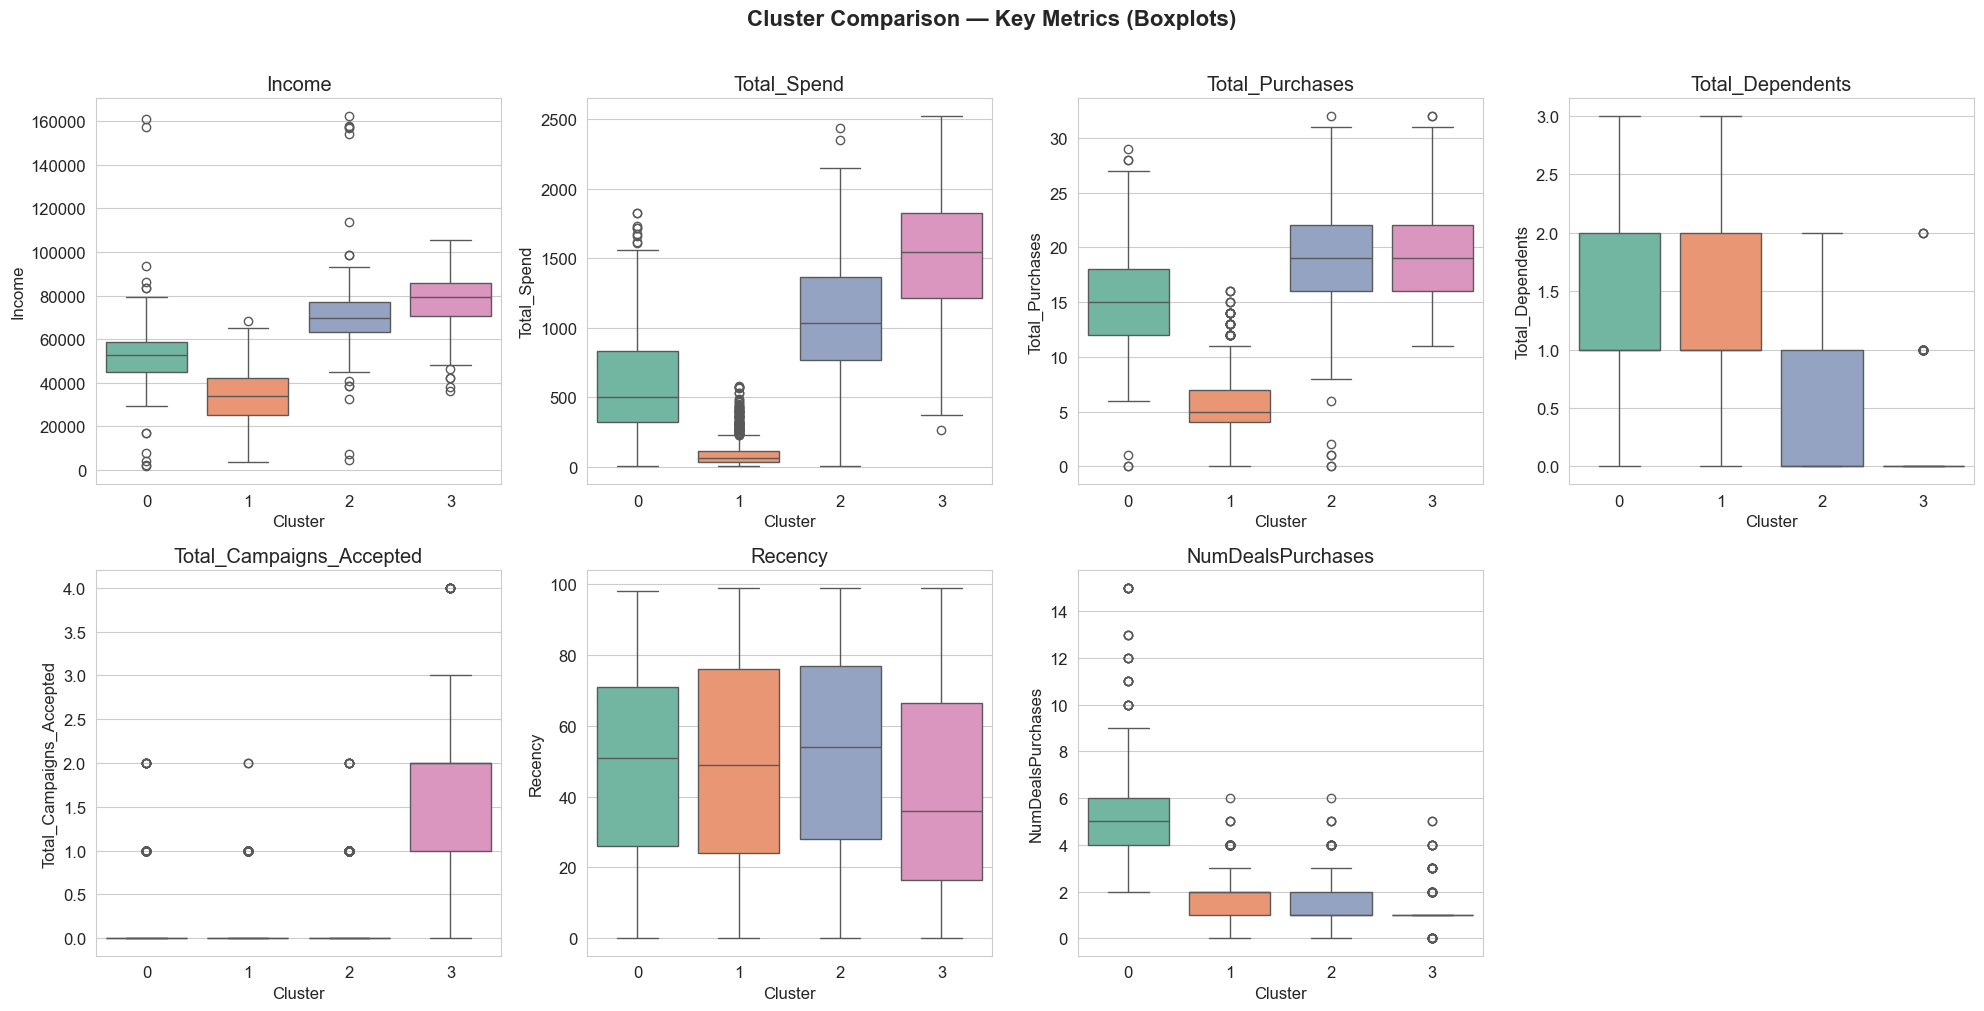

In [17]:
# Boxplots for key features
key_features = ['Income', 'Total_Spend', 'Total_Purchases', 'Total_Dependents',
                'Total_Campaigns_Accepted', 'Recency', 'NumDealsPurchases']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(x='Cluster', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col)

axes[-1].set_visible(False)
plt.suptitle('Cluster Comparison — Key Metrics (Boxplots)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 7c. Detailed Profiles & Auto-Labeling

In [18]:
# Print detailed profiles
print('='*70)
print('CLUSTER PROFILES FOR BUSINESS LABELING')
print('='*70)

for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    print(f'\n--- Cluster {cluster} ({len(cluster_data)} customers, {len(cluster_data)/len(df)*100:.1f}%) ---')
    print(f'  Income:              ${cluster_data["Income"].mean():,.0f} avg')
    print(f'  Total Spend:         ${cluster_data["Total_Spend"].mean():,.0f} avg')
    print(f'  Total Purchases:     {cluster_data["Total_Purchases"].mean():.1f} avg')
    print(f'  Total Dependents:    {cluster_data["Total_Dependents"].mean():.1f} avg')
    print(f'  Campaigns Accepted:  {cluster_data["Total_Campaigns_Accepted"].mean():.2f} avg')
    print(f'  Deal Purchases:      {cluster_data["NumDealsPurchases"].mean():.1f} avg')
    print(f'  Web Visits/Month:    {cluster_data["NumWebVisitsMonth"].mean():.1f} avg')
    print(f'  Recency:             {cluster_data["Recency"].mean():.1f} days avg')
    print(f'  Last Campaign Response Rate: {cluster_data["Response"].mean()*100:.1f}%')

CLUSTER PROFILES FOR BUSINESS LABELING

--- Cluster 0 (409 customers, 18.3%) ---
  Income:              $52,515 avg
  Total Spend:         $605 avg
  Total Purchases:     15.2 avg
  Total Dependents:    1.5 avg
  Campaigns Accepted:  0.21 avg
  Deal Purchases:      5.3 avg
  Web Visits/Month:    6.7 avg
  Recency:             49.4 days avg
  Last Campaign Response Rate: 16.4%

--- Cluster 1 (973 customers, 43.5%) ---
  Income:              $34,054 avg
  Total Spend:         $97 avg
  Total Purchases:     5.8 avg
  Total Dependents:    1.2 avg
  Campaigns Accepted:  0.08 avg
  Deal Purchases:      1.8 avg
  Web Visits/Month:    6.5 avg
  Recency:             48.8 days avg
  Last Campaign Response Rate: 7.6%

--- Cluster 2 (627 customers, 28.0%) ---
  Income:              $70,207 avg
  Total Spend:         $1,066 avg
  Total Purchases:     18.7 avg
  Total Dependents:    0.5 avg
  Campaigns Accepted:  0.22 avg
  Deal Purchases:      1.6 avg
  Web Visits/Month:    3.2 avg
  Recency:      

In [19]:
# Auto-label clusters based on their profiles vs overall averages
overall_means = {
    'Income': df['Income'].mean(),
    'Total_Spend': df['Total_Spend'].mean(),
    'Total_Dependents': df['Total_Dependents'].mean(),
    'Total_Campaigns_Accepted': df['Total_Campaigns_Accepted'].mean(),
    'NumDealsPurchases': df['NumDealsPurchases'].mean()
}

cluster_means_all = df.groupby('Cluster')[list(overall_means.keys())].mean()

cluster_labels = {}
for cluster in sorted(df['Cluster'].unique()):
    m = cluster_means_all.loc[cluster]
    
    high_income = m['Income'] > overall_means['Income'] * 1.2
    high_spend = m['Total_Spend'] > overall_means['Total_Spend'] * 1.5
    low_income = m['Income'] < overall_means['Income'] * 0.8
    low_spend = m['Total_Spend'] < overall_means['Total_Spend'] * 0.5
    high_campaigns = m['Total_Campaigns_Accepted'] > overall_means['Total_Campaigns_Accepted'] * 2
    high_dependents = m['Total_Dependents'] > overall_means['Total_Dependents'] * 1.2
    high_deals = m['NumDealsPurchases'] > overall_means['NumDealsPurchases'] * 1.5
    
    if high_income and high_spend and high_campaigns:
        label = 'Premium Loyal'
    elif high_income and high_spend:
        label = 'High-Value'
    elif low_income and low_spend:
        label = 'Budget-Conscious'
    elif high_dependents and high_deals:
        label = 'Deal-Seeking Parents'
    else:
        label = 'Average Mainstream'
    
    cluster_labels[cluster] = label
    count = (df['Cluster'] == cluster).sum()
    pct = count / len(df) * 100
    print(f'Cluster {cluster} → {label:25s} ({count} customers, {pct:.1f}%)')
    print(f'           Income: ${m["Income"]:,.0f}  |  Spend: ${m["Total_Spend"]:,.0f}  |  '
          f'Dependents: {m["Total_Dependents"]:.1f}  |  Campaigns: {m["Total_Campaigns_Accepted"]:.2f}  |  '
          f'Deals: {m["NumDealsPurchases"]:.1f}')

df['Cluster_Label'] = df['Cluster'].map(cluster_labels)
print(f'\nLabels applied!')
print(df['Cluster_Label'].value_counts())

Cluster 0 → Deal-Seeking Parents      (409 customers, 18.3%)
           Income: $52,515  |  Spend: $605  |  Dependents: 1.5  |  Campaigns: 0.21  |  Deals: 5.3
Cluster 1 → Budget-Conscious          (973 customers, 43.5%)
           Income: $34,054  |  Spend: $97  |  Dependents: 1.2  |  Campaigns: 0.08  |  Deals: 1.8
Cluster 2 → High-Value                (627 customers, 28.0%)
           Income: $70,207  |  Spend: $1,066  |  Dependents: 0.5  |  Campaigns: 0.22  |  Deals: 1.6
Cluster 3 → Premium Loyal             (227 customers, 10.2%)
           Income: $77,237  |  Spend: $1,517  |  Dependents: 0.2  |  Campaigns: 1.59  |  Deals: 1.3

Labels applied!
Cluster_Label
Budget-Conscious        973
High-Value              627
Deal-Seeking Parents    409
Premium Loyal           227
Name: count, dtype: int64


### 7d. Final Visualization — All Customers Labeled

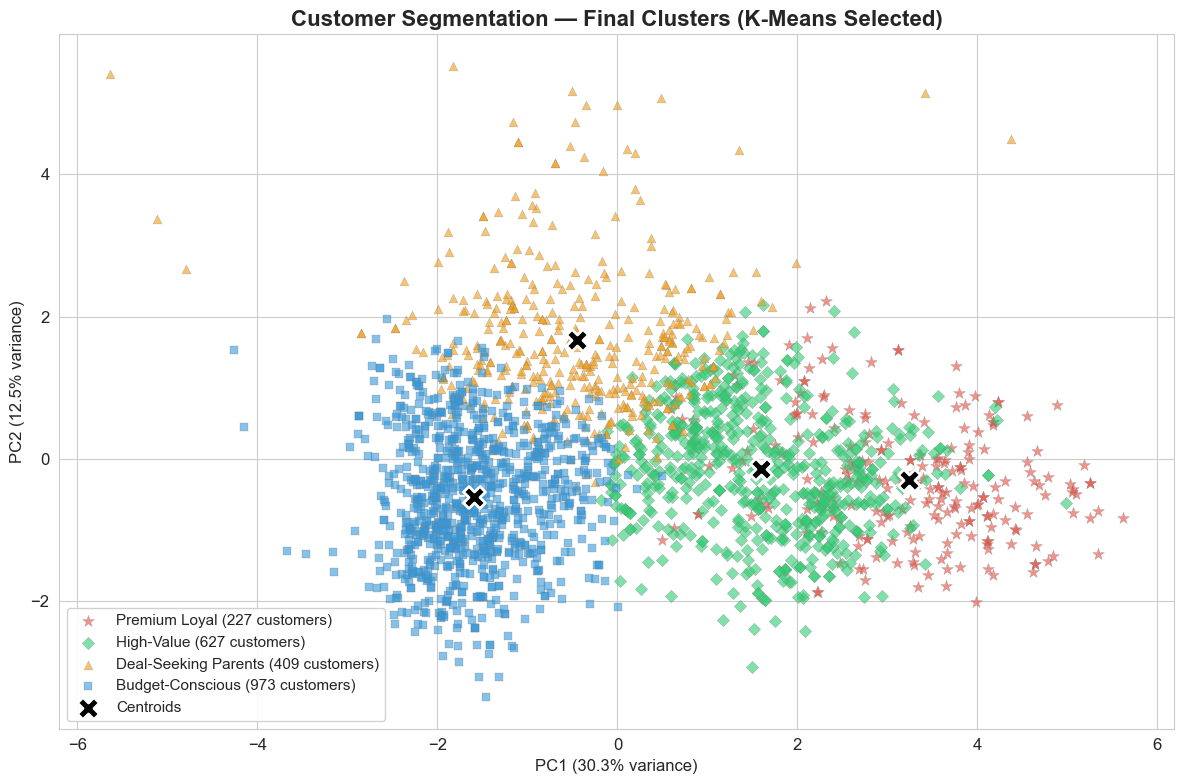

In [20]:
# Final labeled PCA scatter
segment_styles = {
    'Premium Loyal':        {'color': '#e74c3c', 'marker': '*',  'size': 80},
    'High-Value':           {'color': '#2ecc71', 'marker': 'D',  'size': 40},
    'Deal-Seeking Parents': {'color': '#f39c12', 'marker': '^',  'size': 40},
    'Budget-Conscious':     {'color': '#3498db', 'marker': 's',  'size': 30},
    'Average Mainstream':   {'color': '#9b59b6', 'marker': 'o',  'size': 30},
}

fig, ax = plt.subplots(figsize=(12, 8))

for label, style in segment_styles.items():
    mask = df['Cluster_Label'] == label
    if mask.sum() > 0:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=style['color'], marker=style['marker'], s=style['size'],
                   alpha=0.6, edgecolors='gray', linewidth=0.3,
                   label=f'{label} ({mask.sum()} customers)')

centroids_pca = pca_2d.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X',
           s=250, edgecolors='white', linewidth=2, zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Customer Segmentation — Final Clusters (K-Means Selected)', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='best', framealpha=0.9)
plt.tight_layout()
plt.show()

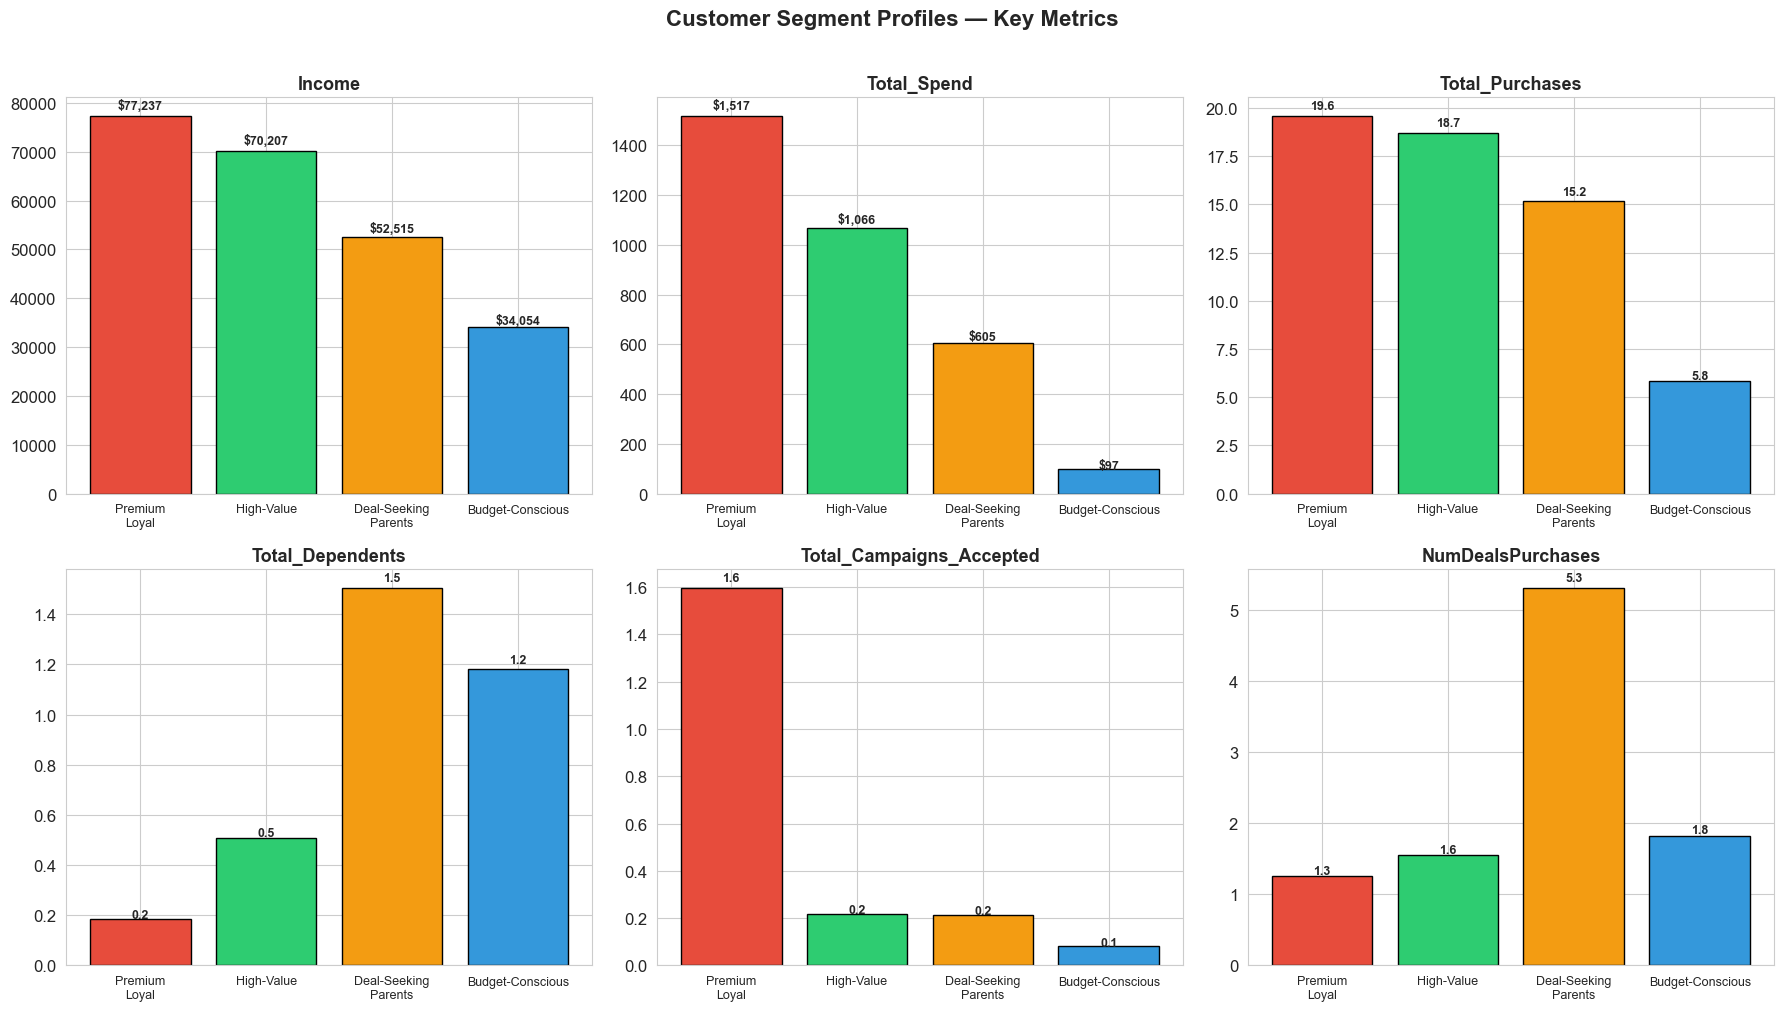


FINAL CUSTOMER SEGMENTATION RESULTS

Premium Loyal (227 customers | 10.2%)
  Income: $77,237  |  Spend: $1,517  |  Purchases: 19.6
  Dependents: 0.2  |  Campaigns: 1.59  |  Deals: 1.3

High-Value (627 customers | 28.0%)
  Income: $70,207  |  Spend: $1,066  |  Purchases: 18.7
  Dependents: 0.5  |  Campaigns: 0.22  |  Deals: 1.6

Deal-Seeking Parents (409 customers | 18.3%)
  Income: $52,515  |  Spend: $605  |  Purchases: 15.2
  Dependents: 1.5  |  Campaigns: 0.21  |  Deals: 5.3

Budget-Conscious (973 customers | 43.5%)
  Income: $34,054  |  Spend: $97  |  Purchases: 5.8
  Dependents: 1.2  |  Campaigns: 0.08  |  Deals: 1.8


In [21]:
# Summary bar charts per segment
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

summary_features = ['Income', 'Total_Spend', 'Total_Purchases', 
                    'Total_Dependents', 'Total_Campaigns_Accepted', 'NumDealsPurchases']
seg_colors = ['#e74c3c', '#2ecc71', '#f39c12', '#3498db']

label_order = df.groupby('Cluster_Label')['Income'].mean().sort_values(ascending=False).index

for i, col in enumerate(summary_features):
    means = df.groupby('Cluster_Label')[col].mean().reindex(label_order)
    bars = axes[i].bar(range(len(means)), means.values, color=seg_colors[:len(means)], edgecolor='black')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xticks(range(len(means)))
    axes[i].set_xticklabels([l.replace(' ', '\n') for l in means.index], fontsize=9)
    for bar in bars:
        height = bar.get_height()
        label_text = f'${height:,.0f}' if col in ['Income', 'Total_Spend'] else f'{height:.1f}'
        axes[i].text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                     label_text, ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Customer Segment Profiles — Key Metrics', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print final summary
print('\n' + '='*80)
print('FINAL CUSTOMER SEGMENTATION RESULTS')
print('='*80)
for label in label_order:
    seg = df[df['Cluster_Label'] == label]
    print(f'\n{label} ({len(seg)} customers | {len(seg)/len(df)*100:.1f}%)')
    print(f'  Income: ${seg["Income"].mean():,.0f}  |  Spend: ${seg["Total_Spend"].mean():,.0f}  |  '
          f'Purchases: {seg["Total_Purchases"].mean():.1f}')
    print(f'  Dependents: {seg["Total_Dependents"].mean():.1f}  |  '
          f'Campaigns: {seg["Total_Campaigns_Accepted"].mean():.2f}  |  '
          f'Deals: {seg["NumDealsPurchases"].mean():.1f}')

## Step 8: Save Model & Data

| File | What It Contains | Used For |
|---|---|---|
| `scaler.pkl` | Trained StandardScaler (means & stds) | Scaling new customer data |
| `kmeans_model.pkl` | Trained K-Means model (4 centroids) | Predicting new customer segments |
| `customer_segmentation_clustered.csv` | Full dataset + Cluster + Cluster_Label | Final presentation |

In [22]:
# Save model artifacts
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(kmeans, 'kmeans_model.pkl')
print('Model artifacts saved:')
print('  scaler.pkl — StandardScaler')
print('  kmeans_model.pkl — Trained KMeans model (selected over Hierarchical & DBSCAN)')

# Save clustered dataset
df.to_csv('customer_segmentation_clustered.csv', index=False)
print(f'\nClustered dataset saved: customer_segmentation_clustered.csv ({df.shape})')

Model artifacts saved:
  scaler.pkl — StandardScaler
  kmeans_model.pkl — Trained KMeans model (selected over Hierarchical & DBSCAN)

Clustered dataset saved: customer_segmentation_clustered.csv ((2236, 14))
